# Module 4 — Community Risk Dashboard
Combines burn severity, terrain, and soil runoff potential into a single
erosion-susceptibility layer, then summarizes it by sub-watershed to answer
the question communities actually need answered:

> "Which parts of the watershed need post-fire monitoring first?" 

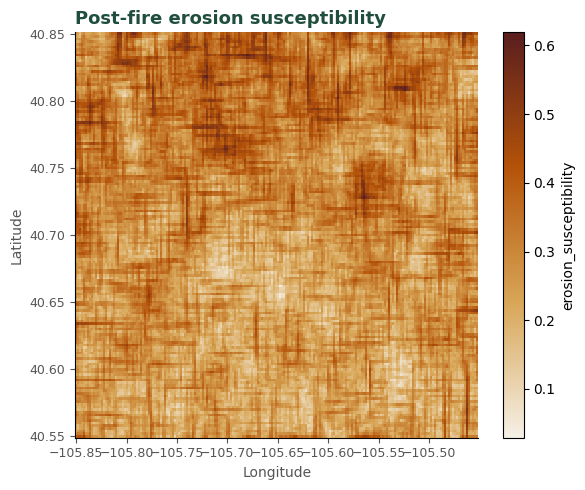

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import daear_toolkit as dt
from daear_toolkit import data_access, indicators, viz

REGION = dt.POUDRE_CAMERON_PEAK
BBOX = REGION.bbox

burn = data_access.get_burn_severity(BBOX, fire_year=REGION.fire_year)
terrain = data_access.get_terrain(BBOX)
soil = data_access.get_soil_properties(BBOX)

erosion = indicators.erosion_susceptibility(terrain["slope_deg"], burn, soil["runoff_potential"])
fig, ax = plt.subplots(figsize=(6, 5))
viz.plot_raster(erosion, title="Post-fire erosion susceptibility", ax=ax, cmap=viz.SEVERITY_CMAP)
plt.tight_layout()
plt.savefig("../outputs/04_erosion_susceptibility.png", dpi=150)
plt.show()

## Split into illustrative sub-watersheds and rank by risk

In [2]:
# Illustrative sub-watershed split: divide the bbox into a 3x3 grid as a
# stand-in for real HUC-12 sub-watershed boundaries (a live deployment would
# use actual NHD/WBD polygons instead of an even grid).
lat = erosion["lat"].values
lon = erosion["lon"].values
lat_bins = np.array_split(np.arange(len(lat)), 3)
lon_bins = np.array_split(np.arange(len(lon)), 3)

rows = []
names = [f"Sub-watershed {chr(65+r)}{c+1}" for r in range(3) for c in range(3)]
i = 0
for r, lat_idx in enumerate(lat_bins):
    for c, lon_idx in enumerate(lon_bins):
        block = erosion.isel(lat=lat_idx, lon=lon_idx)
        rows.append({
            "sub_watershed": names[i],
            "mean_erosion_susceptibility": float(block.mean()),
            "max_erosion_susceptibility": float(block.max()),
            "pct_high_risk_area": float((block > 0.6).mean()) * 100,
        })
        i += 1

risk_table = pd.DataFrame(rows).sort_values("mean_erosion_susceptibility", ascending=False).reset_index(drop=True)
risk_table.round(3)

,sub_watershed,mean_erosion_susceptibility,max_erosion_susceptibility,pct_high_risk_area
0,Sub-watershed C2,0.364,0.613,0.030
1,Sub-watershed C1,0.345,0.608,0.030
2,Sub-watershed C3,0.316,0.619,0.061
3,Sub-watershed B3,0.298,0.619,0.030
4,Sub-watershed B1,0.296,0.522,0.000
5,Sub-watershed A1,0.265,0.501,0.000
6,Sub-watershed A3,0.256,0.547,0.000
7,Sub-watershed B2,0.254,0.480,0.000
8,Sub-watershed A2,0.241,0.445,0.000


## Headline output: top monitoring priorities

In [3]:
top3 = risk_table.head(3)
print("Sub-watersheds requiring post-fire monitoring first:\n")
for _, row in top3.iterrows():
    print(f"  - {row['sub_watershed']}: mean erosion susceptibility "
          f"{row['mean_erosion_susceptibility']:.2f}, "
          f"{row['pct_high_risk_area']:.0f}% of area at high risk")

risk_table.to_csv("../outputs/04_subwatershed_risk_ranking.csv", index=False)

Sub-watersheds requiring post-fire monitoring first:

  - Sub-watershed C2: mean erosion susceptibility 0.36, 0% of area at high risk
  - Sub-watershed C1: mean erosion susceptibility 0.35, 0% of area at high risk
  - Sub-watershed C3: mean erosion susceptibility 0.32, 0% of area at high risk


## Summary

This is the artifact meant to go in front of a community or land manager:
a ranked list of sub-watersheds by post-fire erosion/watershed risk, backed
by the burn-severity, terrain, and soil layers built in Modules 1–3. The
same erosion-susceptibility layer and ranking pattern is reused in
`soil-watershed-intelligence` and rolled up further in
`climate-resilience-indicators`.
